In [1]:
import numpy as np
import pandas as pd
import re
import time
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
num_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
print("First review:")
print(X_train[0])

print("\nFirst label:")
print(y_train[0])

First review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]

First label:
1


In [4]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post'
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (25000, 200)
Testing shape: (25000, 200)


In [5]:
def build_rnn():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128),
        SimpleRNN(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
rnn_model = build_rnn()

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

rnn_time = time.time() - start_time

print("RNN Training Time:", rnn_time, "seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.5215 - loss: 0.6891 - val_accuracy: 0.5512 - val_loss: 0.6773
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - accuracy: 0.6474 - loss: 0.5971 - val_accuracy: 0.5668 - val_loss: 0.6748
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 167ms/step - accuracy: 0.7227 - loss: 0.4400 - val_accuracy: 0.5342 - val_loss: 0.8036
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.7574 - loss: 0.3759 - val_accuracy: 0.5426 - val_loss: 0.8868
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.7709 - loss: 0.3591 - val_accuracy: 0.5230 - val_loss: 0.9335
RNN Training Time: 175.5693802833557 seconds


In [7]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred = (rnn_pred > 0.5).astype(int).flatten()

rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred)
rnn_recall = recall_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)

print("RNN Results")
print("Accuracy :", rnn_accuracy)
print("Precision:", rnn_precision)
print("Recall   :", rnn_recall)
print("F1 Score :", rnn_f1)
print("Training Time:", rnn_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step
RNN Results
Accuracy : 0.52828
Precision: 0.5297985332546573
Recall   : 0.5028
F1 Score : 0.5159463120305381
Training Time: 175.5693802833557


In [8]:
def build_lstm():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
lstm_model = build_lstm()

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

lstm_time = time.time() - start_time

print("LSTM Training Time:", lstm_time, "seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 478ms/step - accuracy: 0.5962 - loss: 0.6505 - val_accuracy: 0.5984 - val_loss: 0.6360
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 523ms/step - accuracy: 0.7829 - loss: 0.5024 - val_accuracy: 0.7438 - val_loss: 0.5540
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 522ms/step - accuracy: 0.6684 - loss: 0.5435 - val_accuracy: 0.7256 - val_loss: 0.5547
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 504ms/step - accuracy: 0.8608 - loss: 0.3675 - val_accuracy: 0.8192 - val_loss: 0.5130
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 470ms/step - accuracy: 0.8423 - loss: 0.4012 - val_accuracy: 0.8340 - val_loss: 0.4409
LSTM Training Time: 402.41730523109436 seconds


In [10]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = (lstm_pred > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred)
lstm_recall = recall_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)

print("LSTM Results")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)
print("Training Time:", lstm_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step
LSTM Results
Accuracy : 0.82228
Precision: 0.8913064594463331
Recall   : 0.73408
F1 Score : 0.8050888352708927
Training Time: 402.41730523109436


In [11]:
def build_gru():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128),
        GRU(64),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
gru_model = build_gru()

start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

gru_time = time.time() - start_time

print("GRU Training Time:", gru_time, "seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 570ms/step - accuracy: 0.5530 - loss: 0.6717 - val_accuracy: 0.5964 - val_loss: 0.6363
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 545ms/step - accuracy: 0.6223 - loss: 0.6247 - val_accuracy: 0.6344 - val_loss: 0.6163
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 138s 522ms/step - accuracy: 0.8331 - loss: 0.3779 - val_accuracy: 0.8608 - val_loss: 0.3445
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 519ms/step - accuracy: 0.9147 - loss: 0.2247 - val_accuracy: 0.8790 - val_loss: 0.3195
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 540ms/step - accuracy: 0.9503 - loss: 0.1485 - val_accuracy: 0.8764 - val_loss: 0.3116
GRU Training Time: 483.2374384403229 seconds


In [14]:
gru_pred = gru_model.predict(X_test)

gru_pred = (gru_pred > 0.5).astype(int).flatten()

gru_accuracy = accuracy_score(y_test, gru_pred)
gru_precision = precision_score(y_test, gru_pred)
gru_recall = recall_score(y_test, gru_pred)
gru_f1 = f1_score(y_test, gru_pred)

print("GRU Results")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)
print("Training Time:", gru_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step
GRU Results
Accuracy : 0.87076
Precision: 0.8824160409274693
Recall   : 0.85552
F1 Score : 0.8687599008895568
Training Time: 483.2374384403229


In [15]:
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],
    'Precision': [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],
    'Recall': [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],
    'F1-Score': [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],
    'Training Time (seconds)': [
        rnn_time,
        lstm_time,
        gru_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (seconds)
0,RNN,0.52828,0.529799,0.50280,0.515946,175.569380
1,LSTM,0.82228,0.891306,0.73408,0.805089,402.417305
2,GRU,0.87076,0.882416,0.85552,0.868760,483.237438


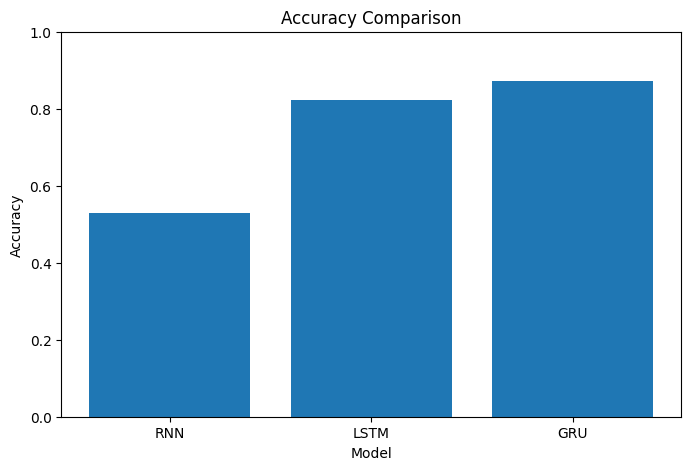

In [16]:
models = ['RNN', 'LSTM', 'GRU']

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

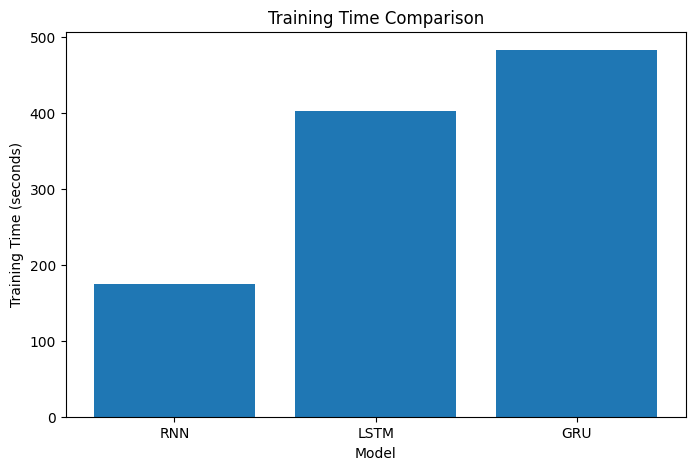

In [17]:
training_times = [
    rnn_time,
    lstm_time,
    gru_time
]

plt.figure(figsize=(8, 5))
plt.bar(models, training_times)
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

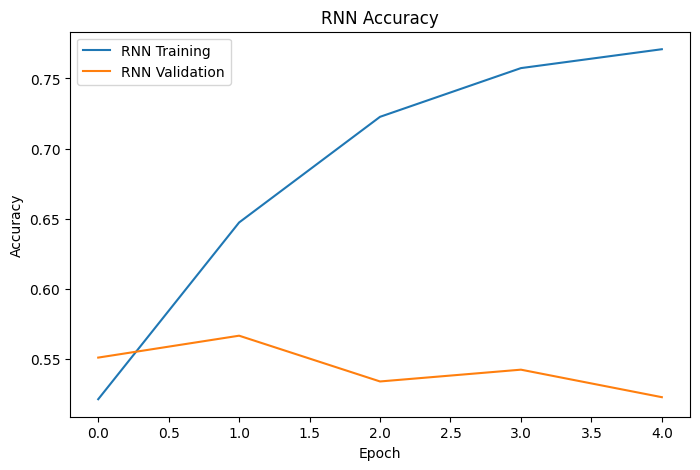

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history['accuracy'], label='RNN Training')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy")
plt.legend()
plt.show()